In [1]:
from os.path import join 

import matplotlib.pyplot as plt 
import numpy as np 
import tidy3d as td 
from tidy3d import web 
from tidy3d.plugins.resonance import ResonanceFinder

00:14:12 Pacific Daylight Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\xtliang\.config\tidy3d'. Found      
                               legacy directory at '~/.tidy3d', which will be   
                               ignored. Remove it manually or run 'tidy3d config
                               migrate --delete-legacy' to clean up.            

In [ ]:
from honeycomb_hex import create_hexagonal_honeycomb_slab
from honeycomb import create_centered_honeycomb_slab

In [2]:
# ── Parameters (match the Lumerical script variables) ────────────────────────
a       = 0.720     # Lattice constant (um)
R       = 10     # Hexagonal radius in unit-cell repeats
radius  = 0.144   # Disk radius (um)  — corresponds to diameter 0.45 um
z_span  = 0.144    # Slab thickness (um)
n_si    = 3.4    # Refractive index of silicon
material = td.Medium(permittivity=n_si**2)

# Twist parameters for double-layer verification
ANGLE   = 9.43    # Twist angle (degrees)
GAP     = 0.47     # Gap between the two slabs (um)

# Simulation run time (s)
run_time = 15e-12

# Randomized source/monitor setup
rng_seed = 20260311
num_sources = 12
num_time_monitors = 12
rand_span_xy = 1.0                 # random x/y range is [-1, 1] um
rand_span_z = GAP + 2 * z_span     # random z range is [-(GAP+2*z_span)/2, +(GAP+2*z_span)/2] um


In [4]:
cyls_bottom = create_centered_honeycomb_slab(
    lattice_const=a, disk_diameter=2*radius, slab_thickness=z_span,
    twist_angle=-ANGLE/2 - 30, domain_size=(2*R*a, 2*R*a), material=material, centerz= - GAP / 2,
)

cyls_top = create_centered_honeycomb_slab(
    lattice_const=a, disk_diameter=2*radius, slab_thickness=z_span,
    twist_angle=ANGLE/2 - 30, domain_size=(2*R*a, 2*R*a), material=material, centerz= GAP / 2,
)
# Build a single td.Structure from all cylinders
all_geom = td.GeometryGroup(geometries=cyls_bottom + cyls_top)
structure = td.Structure(geometry=all_geom, medium=material)

In [ ]:
# sim size
# lx = 4.3796  # 4379.6 nm
# ly = 4.3796 * np.sqrt(3)  # 4379.6*sqrt(3)/2 nm
lx = 2*R*a  # 2*R*a um
ly = 2*R*a*np.sqrt(3)  # 2*R*a*sqrt(3)/2 um
lz = 4.5  # enlarged to include Gaussian beam waist plane at z = -2 um

In [6]:
steps_per_unit_length = 20
grid_spec = td.GridSpec(
    grid_x=td.UniformGrid(dl=a / steps_per_unit_length),
    grid_y=td.UniformGrid(dl=a / steps_per_unit_length * np.sqrt(3)),
    grid_z=td.AutoGrid(min_steps_per_wvl=steps_per_unit_length),
)

In [7]:
# Simulation run time (s) - for ContinuousWave source
run_time = 15e-12

# Point source at center with frequency 280 THz
freq_source = 280e12  # 280 THz

# Point dipole source
point_source = td.PointDipole(
    center=(0, 0, 0),
    source_time=td.ContinuousWave(freq0=freq_source, fwidth=1e12),
    polarization="Hz",
    name="point_source",
)

sources = [point_source]

print(f"Configured point source at frequency {freq_source/1e12:.1f} THz")


Configured point source at frequency 280.0 THz


In [8]:
# Simple point field monitor
field_monitor = td.FieldMonitor(
    center=(0, 0, 0),
    size=(0, 0, 0),
    freqs=[freq_source],
    name="point_field_monitor",
)

monitors = [field_monitor]

print(f"Configured simple point field monitor at {freq_source/1e12:.1f} THz")


Configured simple point field monitor at 280.0 THz


In [9]:
# Build a probe simulation first to estimate dt for FieldTimeMonitor downsampling.
# sim_probe = td.Simulation(
#     size=(lx, ly, lz),
#     grid_spec=grid_spec,
#     structures=[structure],
#     sources=sources,
#     monitors=time_series_mnts + monitor_projs + [field_mnt_xy, field_mnt_xy_z17],
#     run_time=run_time,
#     boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
#     shutoff=1e-05,
# )

# field_time_target_dt = 0.1e-12
# field_time_interval_steps = max(1, int(np.round(field_time_target_dt / sim_probe.dt)))
# actual_field_time_dt = field_time_interval_steps * sim_probe.dt

field_time_mnt_xy_z17 = td.FieldTimeMonitor(
    center=[0, 0, z_phase_plane],
    size=[lx, ly, 0],
    start=0,
    interval=1,
    name="field_xy_t_z17",
)

# print(f"field_xy_t_z17 interval steps: {field_time_interval_steps}")
# print(f"Requested dt: {field_time_target_dt:.3e} s, actual dt: {actual_field_time_dt:.3e} s")

NameError: name 'z_phase_plane' is not defined

In [10]:
# Simulation
sim = td.Simulation(
    size=(lx, ly, lz),
    grid_spec=grid_spec,
    structures=[structure],
    sources=sources,
    monitors=monitors,
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    shutoff=1e-05,
)

print(f"Total number of grid points (millions): {sim.num_cells / 1e6:1.4f}")
print(f"Total number of time steps: {sim.num_time_steps}")
print(f"Number of sources: {len(sources)}")
print(f"Number of monitors: {len(monitors)}")


19:15:42 Pacific Daylight Time WARNING: The grid step in y has a value of 0.0624
                               (um), which was detected as being large when     
                               compared to the central wavelength of sources[0] 
                               within the medium associated with structures[0], 
                               given by 0.3149 (um). To avoid inaccuracies, it  
                               is recommended the grid size is reduced.         

                               WARNING: 'normalize_index' 0 is a source with    
                               'ContinuousWave' time dependence. Normalizing    
                               frequency-domain monitors by this source is not  
                               meaningful because field decay does not occur.   
                               Consider setting 'normalize_index' to 'None'     
                               instead.                                         

Total number of grid points (millions): 3.0056
Total number of time steps: 324007
Number of sources: 1
Number of monitors: 1


In [11]:
# sim_data = web.load(task_id="fdve-10d8a995-c992-477f-860a-dd7800004c9a", path="data/JieYao_v5.hdf5", verbose=True)
sim_data = td.SimulationData.from_file("data/JieYao_v13.hdf5")

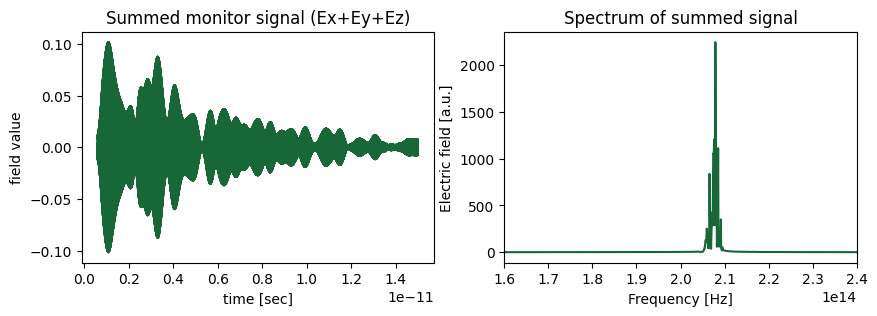

In [12]:
# Sum Ex + Ey + Ez across all randomized point monitors.
time_monitor_names = [mnt.name for mnt in time_series_mnts]

summed_signal = None
for name in time_monitor_names:
    tdata = sim_data[name]
    signal_xyz = tdata.Ex.squeeze() + tdata.Ey.squeeze() + tdata.Ez.squeeze()
    summed_signal = signal_xyz if summed_signal is None else (summed_signal + signal_xyz)

# Optional normalization by number of monitors.
time_series = summed_signal / len(time_monitor_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot time dependence
time_series.plot(ax=ax1)
ax1.set_title("Summed monitor signal (Ex+Ey+Ez)")

# Make frequency mesh and plot spectrum
dt = sim_data.simulation.dt
fmesh = np.linspace(-1 / dt / 2, 1 / dt / 2, time_series.size)
spectrum = np.fft.fftshift(np.fft.fft(time_series))

ax2.plot(fmesh, np.abs(spectrum))
ax2.set_xlim(1.6e14, 2.4e14)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Electric field [a.u.]")
ax2.set_title("Spectrum of summed signal")
plt.show()

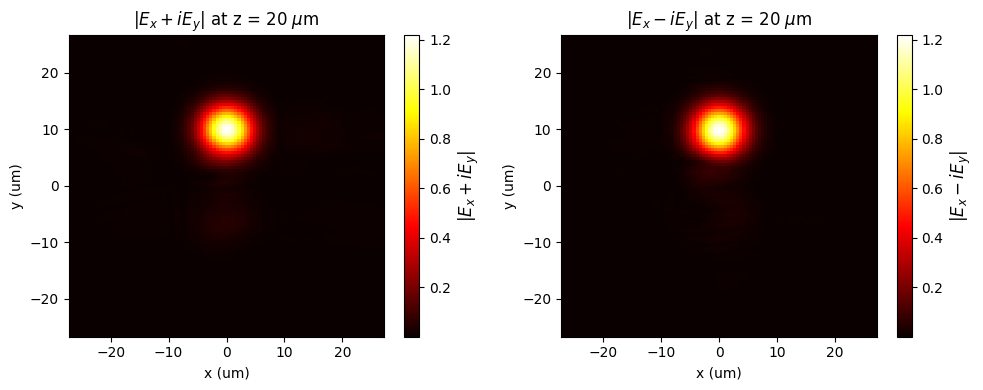

In [18]:
proj_fields = sim_data["focal_plane_proj_05"].fields_cartesian.sel(f=freq1, z=z_proj)

RCP = np.abs(proj_fields.Ex + 1j * proj_fields.Ey)
LCP = np.abs(proj_fields.Ex - 1j * proj_fields.Ey)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = ax1.pcolormesh(xs_far, ys_far, abs(proj_fields.Ex), cmap="hot", shading="auto")
im2 = ax2.pcolormesh(xs_far, ys_far, abs(proj_fields.Ey), cmap="hot", shading="auto")

cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label(r"$|E_x + iE_y|$", fontsize=12)

cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label(r"$|E_x - iE_y|$", fontsize=12)

ax1.set_xlabel("x (um)")
ax1.set_ylabel("y (um)")
ax1.set_title(r"$|E_x + iE_y|$ at z = 20 $\mu$m")

ax2.set_xlabel("x (um)")
ax2.set_ylabel("y (um)")
ax2.set_title(r"$|E_x - iE_y|$ at z = 20 $\mu$m")

plt.tight_layout()
plt.show()

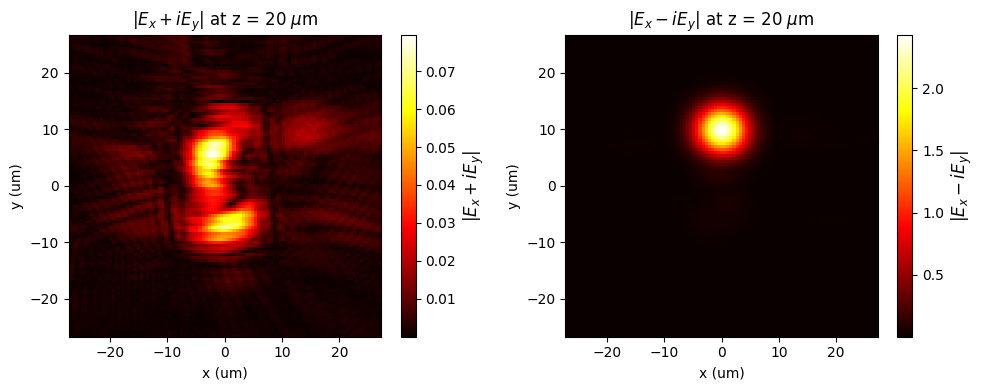

In [17]:
proj_fields = sim_data["focal_plane_proj_05"].fields_cartesian.sel(f=freq1, z=z_proj)

RCP = np.abs(proj_fields.Ex + 1j * proj_fields.Ey)
LCP = np.abs(proj_fields.Ex - 1j * proj_fields.Ey)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = ax1.pcolormesh(xs_far, ys_far, RCP, cmap="hot", shading="auto")
im2 = ax2.pcolormesh(xs_far, ys_far, LCP, cmap="hot", shading="auto")

cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label(r"$|E_x + iE_y|$", fontsize=12)

cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label(r"$|E_x - iE_y|$", fontsize=12)

ax1.set_xlabel("x (um)")
ax1.set_ylabel("y (um)")
ax1.set_title(r"$|E_x + iE_y|$ at z = 20 $\mu$m")

ax2.set_xlabel("x (um)")
ax2.set_ylabel("y (um)")
ax2.set_title(r"$|E_x - iE_y|$ at z = 20 $\mu$m")

plt.tight_layout()
plt.show()

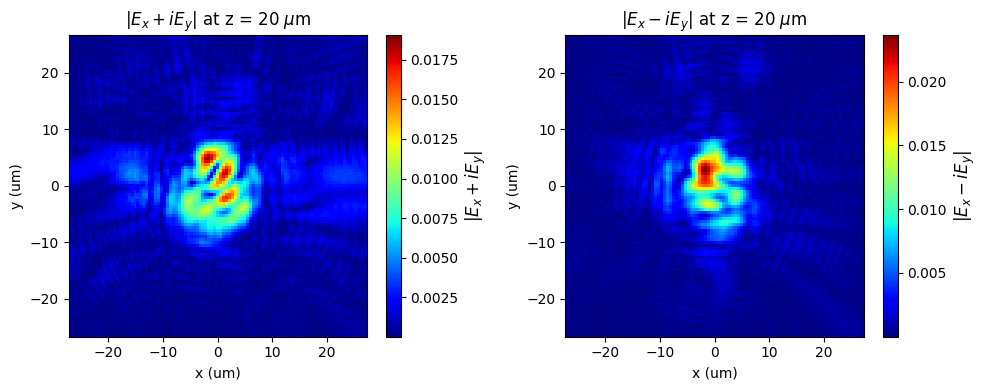

In [21]:
proj_fields = sim_data["focal_plane_proj_04"].fields_cartesian.sel(f=freq1, z=z_proj)

RCP = np.angle(proj_fields.Ex + 1j * proj_fields.Ey)
LCP = np.angle(proj_fields.Ex - 1j * proj_fields.Ey)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = ax1.pcolormesh(xs_far, ys_far, np.abs(proj_fields.Ex), cmap="jet", shading="auto")
im2 = ax2.pcolormesh(xs_far, ys_far, np.abs(proj_fields.Ey), cmap="jet", shading="auto")

cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label(r"$|E_x + iE_y|$", fontsize=12)

cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label(r"$|E_x - iE_y|$", fontsize=12)

ax1.set_xlabel("x (um)")
ax1.set_ylabel("y (um)")
ax1.set_title(r"$|E_x + iE_y|$ at z = 20 $\mu$m")

ax2.set_xlabel("x (um)")
ax2.set_ylabel("y (um)")
ax2.set_title(r"$|E_x - iE_y|$ at z = 20 $\mu$m")

plt.tight_layout()
plt.show()

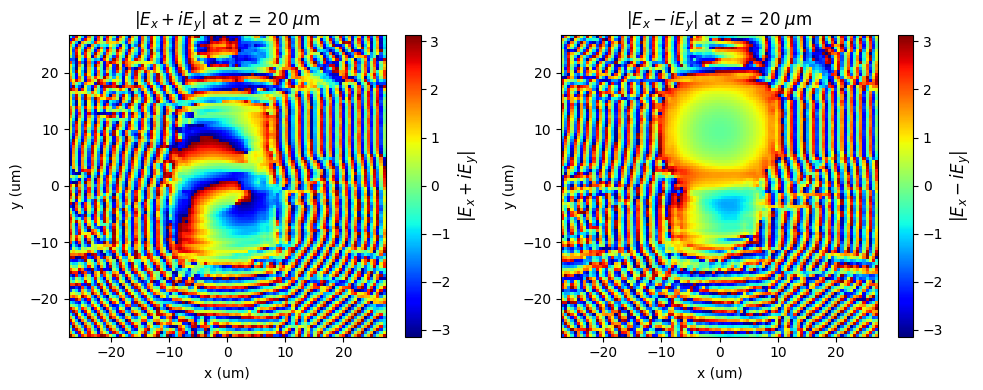

In [19]:
proj_fields = sim_data["focal_plane_proj_05"].fields_cartesian.sel(f=freq1, z=z_proj)

RCP = np.angle(proj_fields.Ex + 1j * proj_fields.Ey)
LCP = np.angle(proj_fields.Ex - 1j * proj_fields.Ey)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = ax1.pcolormesh(xs_far, ys_far, RCP, cmap="jet", shading="auto")
im2 = ax2.pcolormesh(xs_far, ys_far, LCP, cmap="jet", shading="auto")

cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label(r"$|E_x + iE_y|$", fontsize=12)

cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label(r"$|E_x - iE_y|$", fontsize=12)

ax1.set_xlabel("x (um)")
ax1.set_ylabel("y (um)")
ax1.set_title(r"$|E_x + iE_y|$ at z = 20 $\mu$m")

ax2.set_xlabel("x (um)")
ax2.set_ylabel("y (um)")
ax2.set_title(r"$|E_x - iE_y|$ at z = 20 $\mu$m")

plt.tight_layout()
plt.show()